# EXERCISE 4: Feature Extraction and Object Detection

## HOG (Histogram of Oriented Gradients) Object Detection

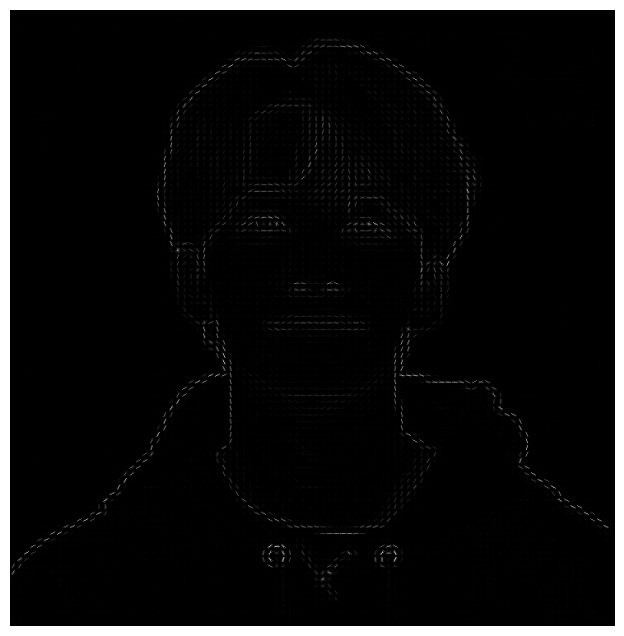

In [ ]:
import cv2
from skimage.feature import hog
import matplotlib.pyplot as plt

# Load an image
image = cv2.imread('image.jpg')
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# Apply HOG descriptor without the channel_axis parameter
features, hog_image = hog(gray_image, orientations=9, pixels_per_cell=(8, 8), cells_per_block=(2, 2), visualize=True)

# Display the HOG image
plt.figure(figsize=(8, 8))
plt.axis('off')
plt.imshow(hog_image, cmap='gray')
plt.show()


## YOLO (You Only Look Once) Object Detection

In [ ]:
# Step 1: Download YOLOv3 weights and configuration files
!wget https://pjreddie.com/media/files/yolov3.weights -O yolov3.weights
!wget https://github.com/pjreddie/darknet/raw/master/cfg/yolov3.cfg -O yolov3.cfg

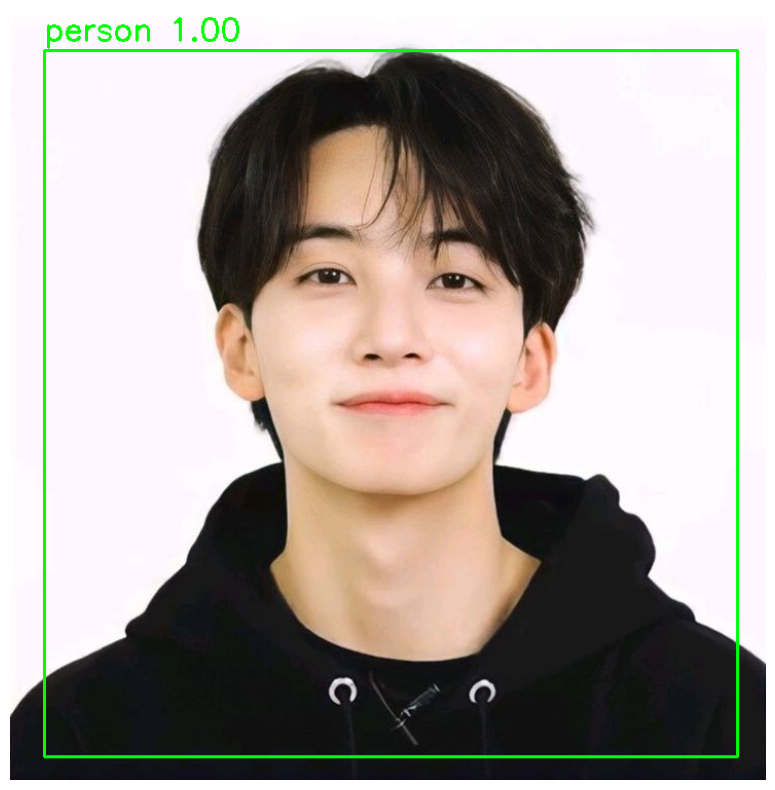

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Step 2: Load YOLO model and configuration
net = cv2.dnn.readNet("/content/yolov3.weights", "/content/yolov3.cfg")
layer_names = net.getLayerNames()
unconnected_out_layers = net.getUnconnectedOutLayers()

# Adjust for OpenCV version differences
if isinstance(unconnected_out_layers, int):
    output_layers = [layer_names[unconnected_out_layers - 1]]
else:
    output_layers = [layer_names[i - 1] for i in unconnected_out_layers.flatten()]

# Load COCO class names (labels)
with open('/content/coco.names', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

# Step 3: Load the image
image_filename = "/content/image.jpg"  # Replace with your actual file path
image = cv2.imread(image_filename)
height, width, _ = image.shape

# Step 4: Prepare the image for YOLO
blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), swapRB=True, crop=False)
net.setInput(blob)
outs = net.forward(output_layers)

# Step 5: Extract bounding boxes, class IDs, and confidence scores
boxes = []
confidences = []
class_ids = []

for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > 0.5:  # Confidence threshold
            center_x = int(detection[0] * width)
            center_y = int(detection[1] * height)
            w = int(detection[2] * width)
            h = int(detection[3] * height)
            x = int(center_x - w / 2)
            y = int(center_y - h / 2)
            boxes.append([x, y, w, h])
            confidences.append(float(confidence))
            class_ids.append(class_id)

# Apply Non-Maximum Suppression (NMS)
indices = cv2.dnn.NMSBoxes(boxes, confidences, 0.5, 0.4)  # Confidence and NMS thresholds

# Draw bounding boxes and labels
def draw_bounding_boxes(image, boxes, class_ids, confidences, indices):
    if len(indices) > 0:  # Check if NMS returned any valid boxes
        for i in indices.flatten():  # Use flatten() to handle 1D arrays
            box = boxes[i]
            x, y, w, h = box
            label = str(classes[class_ids[i]])
            confidence = confidences[i]
            cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
            cv2.putText(image, f'{label} {confidence:.2f}', (x, y - 10),
                        cv2.FONT_HERSHEY_SIMPLEX, 1.0, (0, 255, 0), 2)
    return image

# Draw the bounding boxes on the image using NMS-filtered indices
image_with_boxes = draw_bounding_boxes(image, boxes, class_ids, confidences, indices)

# Display the result using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(cv2.cvtColor(image_with_boxes, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.show()


## SSD (Single Shot MultiBox Detector) with Tensorflow

In [ ]:
!wget http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz
!tar -xzvf ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz

--2024-10-29 05:34:42--  http://download.tensorflow.org/models/object_detection/tf2/20200711/ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz
Resolving download.tensorflow.org (download.tensorflow.org)... 142.250.145.207, 74.125.128.207, 74.125.143.207, ...
Connecting to download.tensorflow.org (download.tensorflow.org)|142.250.145.207|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 46042990 (44M) [application/x-tar]
Saving to: ‘ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz’

ssd_mobilenet_v2_32 100%[===================>]  43.91M  23.4MB/s    in 1.9s    

2024-10-29 05:34:44 (23.4 MB/s) - ‘ssd_mobilenet_v2_320x320_coco17_tpu-8.tar.gz’ saved [46042990/46042990]

ssd_mobilenet_v2_320x320_coco17_tpu-8/
ssd_mobilenet_v2_320x320_coco17_tpu-8/checkpoint/
ssd_mobilenet_v2_320x320_coco17_tpu-8/checkpoint/ckpt-0.data-00000-of-00001
ssd_mobilenet_v2_320x320_coco17_tpu-8/checkpoint/checkpoint
ssd_mobilenet_v2_320x320_coco17_tpu-8/checkpoint/ckpt-0.index
ssd_mobilenet_v2_320x32

In [ ]:
model_2 = tf.saved_model.load('/content/ssd_mobilenet_v2_320x320_coco17_tpu-8/saved_model')

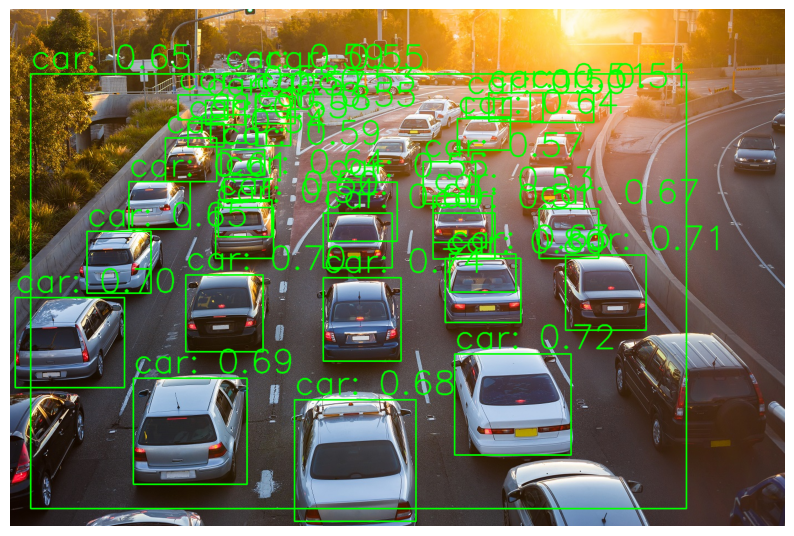

In [ ]:
# Load COCO class names (labels)
with open('/content/coco.names', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

# Load an input image
image = cv2.imread('/content/AdobeStock_47324734.jpeg')
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convert to RGB

# Prepare input tensor
input_tensor = tf.convert_to_tensor(image_rgb, dtype=tf.uint8)
input_tensor = input_tensor[tf.newaxis, ...]  # Add batch dimension

# Run the model
detections = model_2(input_tensor)

# Extract detection outputs as numpy arrays
num_detections = int(detections.pop('num_detections'))
detections = {key: value[0, :num_detections].numpy() for key, value in detections.items()}
boxes = detections['detection_boxes']  # Shape: [num_detections, 4]
scores = detections['detection_scores']  # Shape: [num_detections]
class_ids = detections['detection_classes'].astype(np.int32)  # Shape: [num_detections]

# Apply Non-Maximum Suppression (NMS)
nms_indices = tf.image.non_max_suppression(
    boxes=boxes,
    scores=scores,
    max_output_size=100,  # Limit to 100 detections
    iou_threshold=0.5,  # IOU threshold for suppression
    score_threshold=0.5  # Minimum confidence score
).numpy()

# Draw bounding boxes and labels
def draw_bounding_boxes(image, boxes, class_ids, scores, indices):
    h, w, _ = image.shape
    for i in indices:
        # Get the corresponding box and class label
        box = boxes[i]
        label = f"{classes[class_ids[i] - 1]}: {scores[i]:.2f}"  # Adjust index for 0-based classes

        # Convert normalized coordinates to pixel values
        ymin, xmin, ymax, xmax = (int(box[0] * h), int(box[1] * w),
                                  int(box[2] * h), int(box[3] * w))

        # Draw the bounding box
        cv2.rectangle(image, (xmin, ymin), (xmax, ymax), (0, 255, 0), 2)

        # Draw the label above the bounding box
        font_scale = 2.0  # Adjust this value to change font size
        cv2.putText(image, label, (xmin, ymin - 10), cv2.FONT_HERSHEY_SIMPLEX,
                    font_scale, (0, 255, 0), 2, lineType=cv2.LINE_AA)

    return image

# Draw the bounding boxes on the image using NMS-filtered indices
image_with_boxes = draw_bounding_boxes(image_rgb.copy(), boxes, class_ids, scores, nms_indices)

# Display the result using matplotlib
plt.figure(figsize=(10, 10))
plt.imshow(image_with_boxes)
plt.axis('off')
plt.show()

## Traditional vs. Deep Learning Object Detection Comparison

In [ ]:
import cv2
import numpy as np
from sklearn import svm
from sklearn.metrics import accuracy_score
from skimage.feature import hog
import time

# Function to extract HOG features
def extract_hog_features(image):
    return hog(image, orientations=9, pixels_per_cell=(8, 8),
               cells_per_block=(2, 2), visualize=False, block_norm='L2-Hys')

# Load and preprocess two images for demonstration
image1 = cv2.imread('/content/image.jpg', cv2.IMREAD_GRAYSCALE)  # Class 1
image2 = cv2.imread('/content/FCtbEh8WEAsQKq_.jpg', cv2.IMREAD_GRAYSCALE)  # Class 0

# Resize both images
image1 = cv2.resize(image1, (64, 128))
image2 = cv2.resize(image2, (64, 128))

# Extract HOG features for both images
hog1 = extract_hog_features(image1)
hog2 = extract_hog_features(image2)

# Create feature and label arrays
features = [hog1, hog2]  # Two samples with distinct features
labels = [1, 0]  # Two classes (e.g., 1 = positive, 0 = negative)

# Train the SVM classifier
clf = svm.SVC(kernel='linear', probability=True)
start_time = time.time()
clf.fit(features, labels)
hog_training_time = time.time() - start_time

# Predict and evaluate on new data (use one of the images)
prediction = clf.predict([hog1])  # Predict for the first image
accuracy = accuracy_score([1], prediction)  # Compare with the true label

print(f"HOG-SVM Accuracy: {accuracy * 100:.2f}%")
print(f"HOG-SVM Training Time: {hog_training_time:.2f} seconds")

HOG-SVM Accuracy: 100.00%
HOG-SVM Training Time: 0.00 seconds


In [ ]:
import cv2
import numpy as np
import time

# Load YOLO model and configuration
net = cv2.dnn.readNet('/content/yolov3.weights', '/content/yolov3.cfg')
with open('/content/coco.names', 'r') as f:
    classes = [line.strip() for line in f.readlines()]

# Load and preprocess the image
image = cv2.imread('/content/image.jpg')
height, width, _ = image.shape

# Prepare the image for YOLO
blob = cv2.dnn.blobFromImage(image, 0.00392, (416, 416), (0, 0, 0), swapRB=True, crop=False)
net.setInput(blob)

# Perform inference and measure time
start_time = time.time()
outs = net.forward(net.getUnconnectedOutLayersNames())
yolo_inference_time = time.time() - start_time

# Parse detections and calculate accuracy (dummy comparison)
confidence_threshold = 0.5
detections = 0

for out in outs:
    for detection in out:
        scores = detection[5:]
        class_id = np.argmax(scores)
        confidence = scores[class_id]
        if confidence > confidence_threshold:
            detections += 1

print(f"YOLO Detections: {detections}")
print(f"YOLO Inference Time: {yolo_inference_time:.2f} seconds")

YOLO Detections: 8
YOLO Inference Time: 2.35 seconds
